<a href="https://colab.research.google.com/github/andege19/AI-CROP-PROJECT/blob/main/THE_CROP_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Smart Agriculture: AI-Powered Crop Monitoring for Smallholder Farmers**








#Project Overview: AI-Based Crop Monitoring for Small Farmers<br>

This project focuses on using artificial intelligence to help smallholder farmers monitor and maintain the health of their crops. Many farmers in rural and under-resourced areas lack access to modern tools for early disease detection, which often leads to poor yields and economic losses.

By applying deep learning techniques to images of plant leaves, we can create a smart crop-monitoring system that is accurate and efficient. The model in this project uses a convolutional neural network (CNN) trained on a public dataset to classify plant leaves as either healthy or diseased.

**Key goals and features of the project include:**

- **Automated Disease Detection**: A CNN model is trained to analyze plant leaf images and classify them as healthy or diseased.
- **Support for Smallholder Farmers**: Focused on offering an affordable, AI-powered solution that could eventually help farmers without advanced tools.
- **Improved Decision-Making**: Enables detection of potential crop issues, helping in timely interventions and reducing losses.
- **Scalability and Accessibility (Future Scope)**: While not implemented here, this model could later be deployed in mobile or web apps for field use.
- **AI Model Training**: Trained on a labeled dataset of plant leaf images (via TensorFlow Datasets), the model performs binary classification (healthy vs. diseased).
- **Data-Driven Agriculture**: Encourages modern precision agriculture techniques through AI-powered diagnosis.

In summary, this project demonstrates the potential of deep learning in agriculture by developing a basic, yet effective crop health classification system.

## **Data Collection and Preparation**

This section focuses on how the dataset is sourced, organized, and prepared for training a deep learning model.

The notebook utilizes the **PlantVillage dataset**, a widely-used public dataset that contains over 1,500 high-quality images of both healthy and diseased plant leaves. These images represent **14 different crop species** and **26 types of plant diseases**, making it an ideal dataset for training an AI model in agricultural diagnostics.

**Key steps in the data preparation process include:**

- **Downloading the Dataset**: The dataset is retrieved from Tensorflow and automatically extracted into local directories for use in the notebook.

- **Binary Labeling**: The labels are processed so that the model performs binary classification:
  - `0` for healthy leaves
  - `1` for diseased leaves

- **Image Preprocessing**:
  - Images are resized to a standard dimension of `128x128` pixels.
  - Pixel values are normalized to the `[0, 1]` range by dividing by `255.0` to ensure stable training.



#**IMPORTING LIBRARIES**

In this section, we install and import the necessary libraries for building and training our AI model. TensorFlow and TensorFlow Datasets are used to construct the neural network and load the PlantVillage dataset. Matplotlib, NumPy, and Pandas help with data visualization, numerical operations, and basic data handling. We also import Counter from Python’s collections module, which is useful for counting the frequency of labels or classes in the dataset.

In [ ]:
!pip install -q tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

# **DATASET LOADING AND PREPROCESSING**
This line loads the PlantVillage dataset using TensorFlow Datasets (TFDS). It splits the data into 80% for training and 20% for validation.

The **shuffle_files=True** option ensures the data is randomly shuffled for better learning, and **as_supervised=True** returns the data as (image, label) pairs. The **with_info=True** part provides extra metadata (like class names and image shape), which is stored in ds_info.













In [ ]:
(ds_train, ds_val), ds_info = tfds.load(
    'plant_village',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,  # returns (image, label)
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.HRNMX7_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


###**DATA EXPLORATION**

This code gives us an overview of the dataset. It prints the total number of samples, the number of classes (types of diseases or healthy plants), and the shape of each image.

It then separates the class names into two groups;healthy and diseased by checking if the word "healthy" appears in each label.

Finally, it prints how many of the classes are healthy and how many represent plant diseases.

In [ ]:
print("DATASET OVERVIEW")
print(f"Total samples: {ds_info.splits['train'].num_examples}")
print(f"Classes: {ds_info.features['label'].num_classes}")
print(f"Image shape: {ds_info.features['image'].shape}")

original_labels = ds_info.features['label'].names
healthy_labels = [label for label in original_labels if 'healthy' in label.lower()]
diseased_labels = [label for label in original_labels if 'healthy' not in label.lower()]

print(f"Healthy classes: {len(healthy_labels)}")
print(f"Diseased classes: {len(diseased_labels)}")

DATASET OVERVIEW
Total samples: 54303
Classes: 38
Image shape: (None, None, 3)
Healthy classes: 12
Diseased classes: 26


###**DATA VISUALIZATION**

This function displays sample images from the dataset to help us visually understand the types of data we're working with.

It takes 8 images and their labels from the training set, converts them to a displayable format, and arranges them in a 2x4 grid.

Each image is labeled as either “Healthy” or “Diseased” based on its class name, and the crop type is extracted from the label. This visual check helps confirm that the images and labels are correctly loaded and categorized.


 ORIGINAL SAMPLES 


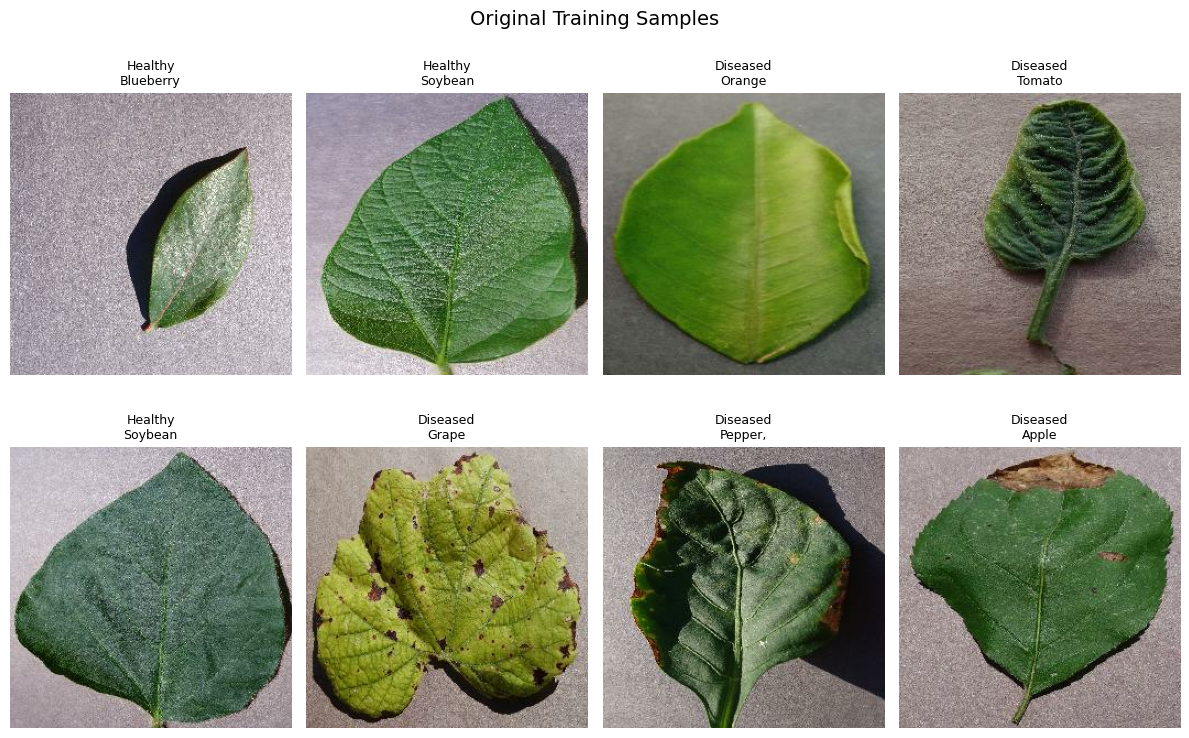

In [ ]:
def visualize_samples(dataset, title="Dataset Samples"):
    plt.figure(figsize=(12, 8))

    # Get individual samples
    sample_images = []
    sample_labels = []

    for image, label in dataset.take(8):  # Take 8 individual samples
        sample_images.append(image.numpy().astype("uint8"))
        sample_labels.append(label.numpy())

    for i in range(len(sample_images)):
        plt.subplot(2, 4, i + 1)
        plt.imshow(sample_images[i])
        label_name = original_labels[sample_labels[i]]
        status = "Healthy" if 'healthy' in label_name.lower() else "Diseased"
        plt.title(f"{status}\n{label_name.split('_')[0]}", fontsize=9)
        plt.axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print("\n ORIGINAL SAMPLES ")
visualize_samples(ds_train, "Original Training Samples")


###**DATA PREPROCESSING**

This code defines a preprocessing function that prepares the dataset for training a binary classification model.

It first creates a list of class indices that represent healthy crops. Then, for each image-label pair, it converts the label into either 0 (healthy) or 1 (diseased) by checking if the label is in the healthy list.

The image is resized to 128x128 pixels and normalized to a [0, 1] range to ensure consistent input size and scale, which helps the model train more effectively.

In [ ]:
healthy_label_indices = [i for i, label in enumerate(original_labels) if 'healthy' in label.lower()]

def preprocess_data(image, label):
    # Binary classification: 0=healthy, 1=diseased
    healthy_indices_tensor = tf.constant(healthy_label_indices, dtype=tf.int64)
    is_healthy = tf.reduce_any(tf.equal(label, healthy_indices_tensor))
    binary_label = tf.cond(is_healthy, lambda: 0, lambda: 1)

    # Image preprocessing
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0  # Normalize

    return image, binary_label


###**DATA AUGMENTATION(TRAINING PURPOSES)**

This function applies data augmentation techniques to improve the model's ability to generalize to new, unseen images.

It randomly flips the image horizontally and vertically, and slightly adjusts its brightness.

These transformations create varied versions of the same image, helping the model become more robust to real-world variations in lighting and orientation during training.

The label remains unchanged since the class of the image doesn’t change with these transformations.

In [ ]:
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.1)
    return image, label


###**FINAL DATASETS PIPELINES**

This section prepares the training and validation datasets for efficient model training.

The training data is first preprocessed and augmented, then shuffled to ensure the model sees a random mix of samples in each epoch.

It is then divided into batches of 32 images and preloaded using prefetch to speed up training.

The validation set is also preprocessed and batched, but not augmented or shuffled, as it’s only used to evaluate the model's performance on unseen data in a consistent way.

In [ ]:
BATCH_SIZE = 32

train_ds = (ds_train
           .map(preprocess_data)
           .map(augment_image)  # Only for training
           .shuffle(1000)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

val_ds = (ds_val
         .map(preprocess_data)
         .batch(BATCH_SIZE)
         .prefetch(tf.data.AUTOTUNE))

###**CLASS DISTRIBUTION ANALYSIS**

This function analyzes the class distribution in the training and validation datasets.

It counts how many samples are labeled as healthy (0) and diseased (1) using Python's Counter.

It then prints the total number and percentage of each class in both datasets.

This helps ensure the model is being trained on a balanced dataset, or at least lets us identify if there’s any class imbalance that could affect training accuracy.

In [ ]:
def analyze_distribution(dataset, name):
    counts = Counter()
    for _, labels in dataset:
        for label in labels:
            counts[label.numpy()] += 1

    total = sum(counts.values())
    print(f"\n{name} Distribution:")
    print(f"Healthy: {counts[0]} ({counts[0]/total*100:.1f}%)")
    print(f"Diseased: {counts[1]} ({counts[1]/total*100:.1f}%)")
    return counts

train_dist = analyze_distribution(train_ds, "Training")
val_dist = analyze_distribution(val_ds, "Validation")



Training Distribution:
Healthy: 12009 (27.6%)
Diseased: 31433 (72.4%)

Validation Distribution:
Healthy: 3074 (28.3%)
Diseased: 7787 (71.7%)


###**VISUALIZE PREPROCESSED DATA**

This function visualizes a few preprocessed images from the training and validation datasets.

It displays up to 6 images from a single batch, labeling each one as either "Healthy" or "Diseased" using bold colored titles (green for healthy, red for diseased).

This visual confirmation helps verify that preprocessing, resizing, normalization, binary labeling, and augmentation (in the training set) have been applied correctly.

The printed messages also summarize the preprocessing steps completed so far, confirming that the dataset is now ready for model training.


PREPROCESSED SAMPLES


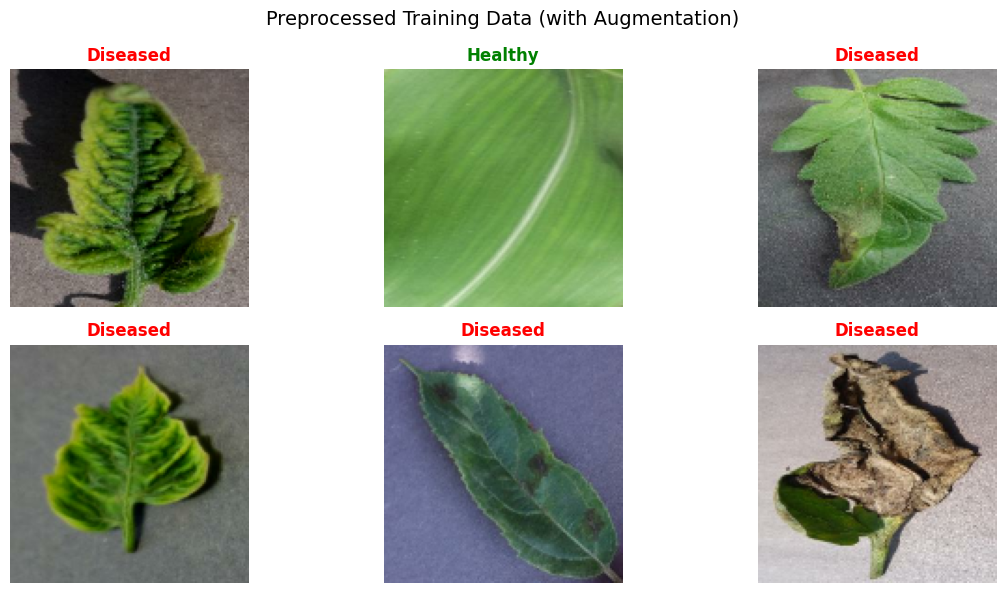

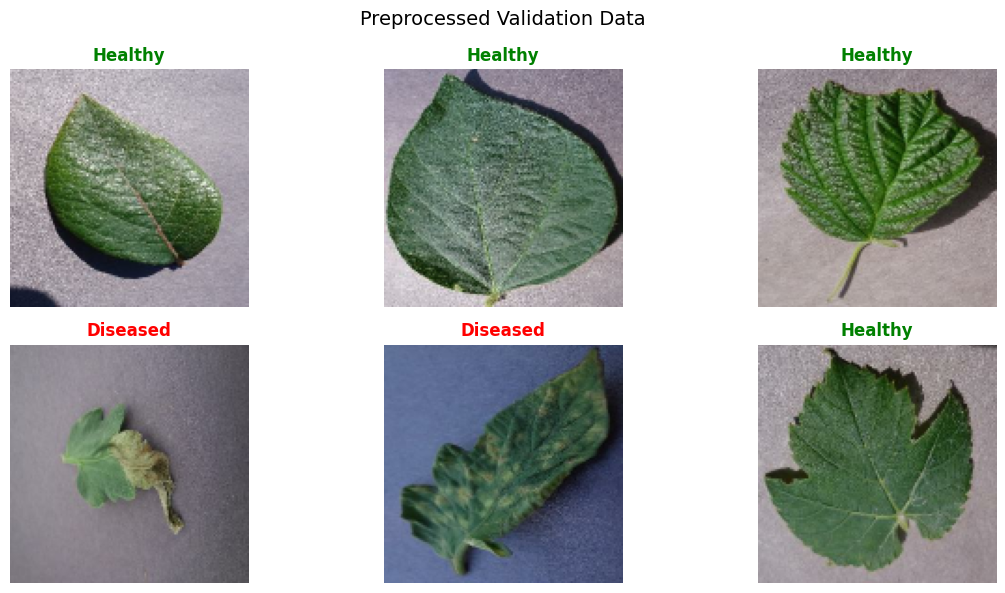


PREPROCESSING COMPLETE
Data loaded and explored
Binary classification applied
Images normalized and resized
Data augmentation added to training
Class distribution analyzed


In [ ]:
def show_preprocessed(dataset, title):
    plt.figure(figsize=(12, 6))

    # Get one batch and handle it properly
    batch_found = False
    for images, labels in dataset.take(1):
        batch_size = tf.shape(images)[0].numpy()
        num_to_show = min(6, batch_size)

        for i in range(num_to_show):
            plt.subplot(2, 3, i + 1)
            plt.imshow(images[i].numpy())
            status = "Healthy" if labels[i].numpy() == 0 else "Diseased"
            color = 'green' if status == "Healthy" else 'red'
            plt.title(status, color=color, fontweight='bold')
            plt.axis('off')
        batch_found = True
        break

    if batch_found:
        plt.suptitle(title, fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data found for {title}")

print("\nPREPROCESSED SAMPLES")
show_preprocessed(train_ds, "Preprocessed Training Data (with Augmentation)")
show_preprocessed(val_ds, "Preprocessed Validation Data")

print("\nPREPROCESSING COMPLETE")
print("Data loaded and explored")
print("Binary classification applied")
print("Images normalized and resized")
print("Data augmentation added to training")
print("Class distribution analyzed")

###**MODEL SELECTION AND TRAINING**

This code builds and compiles a Convolutional Neural Network (CNN) for binary classification of plant leaves.

The model uses three convolutional layers with increasing filter sizes (32, 64, 128), each followed by max-pooling layers to reduce spatial dimensions and capture key features.

The extracted features are flattened and passed through a dense layer with 128 units, followed by a dropout layer (50%) to prevent overfitting.

Finally, a sigmoid-activated output layer predicts either healthy (0) or diseased (1).

The model is compiled using the Adam optimizer, binary cross-entropy loss (suitable for two classes), and accuracy as the evaluation metric.

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # MORE LAYERS FOR feature learning
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Increased dropout
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

###**MODEL TRAINING**

This code begins the training process for the CNN model.

It uses the prepared training dataset (train_ds) and evaluates the model's performance on the validation dataset (val_ds) after each epoch.

The model is trained for 3 full passes through the data (epochs), during which it learns to distinguish between healthy and diseased plant leaves by adjusting its internal parameters.

The training history, including loss and accuracy over time, is stored in the history variable for later analysis or visualization.

In [ ]:
print("Training model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Training model...
Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1545s 1s/step - accuracy: 0.9580 - loss: 0.1137 - val_accuracy: 0.9786 - val_loss: 0.0596
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1533s 1s/step - accuracy: 0.9713 - loss: 0.0761 - val_accuracy: 0.9817 - val_loss: 0.0590
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1622s 1s/step - accuracy: 0.9797 - loss: 0.0588 - val_accuracy: 0.9866 - val_loss: 0.0391


###**IMPROVED VISUALIZATION**

This code generates two plots to visualize the model's training performance over the epochs.

The first plot shows how the accuracy improved for both the training and validation datasets, while the second plot displays how the loss values changed.

These visualizations help identify whether the model is learning effectively or overfitting — for example, if training accuracy increases but validation accuracy plateaus or drops.

Grid lines, legends, and markers make it easier to interpret the trends at each epoch.

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### **FINAL PERFORMANCE**

This code retrieves and prints the final validation accuracy of the trained model to show how well it performs on unseen data.

After evaluation, the model is saved in the .keras format using model.save(), allowing it to be reused later without retraining.

Saving the model is important for deployment or further testing, especially in real-world applications like mobile or web-based crop monitoring tools.











In [ ]:
final_acc = history.history['val_accuracy'][-1]
print(f"\nFinal Validation Accuracy: {final_acc:.4f}")

# SAVE MODEL
model.save('crop_disease_model.keras')
print("Model saved successfully!")



###**EVALUATION AND FINE TUNING**

This section imports libraries used for evaluating and visualizing the model’s performance.

NumPy handles numerical operations, while Matplotlib and Seaborn are used for creating plots like the confusion matrix.

From Scikit-learn, classification_report generates a detailed summary of model performance (precision, recall, F1-score), and confusion_matrix helps visualize how many predictions were correct or incorrect for each class.

These tools are essential for understanding how well the model distinguishes between healthy and diseased leaves.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

###**MODEL EVALUATION ON VALIDATION DATA**

This code generates predictions for the entire validation dataset. It loops through each batch of images in the validation set and uses the trained model to make predictions.

Since the model outputs values between 0 and 1, the predictions are converted into binary labels: values greater than 0.5 are classified as diseased (1), and the rest as healthy (0).

Both the predicted labels and the true labels are stored in separate lists for later evaluation.

In [ ]:
# Get predictions for entire validation set
val_predictions = []
val_true_labels = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    val_predictions.extend((preds > 0.5).astype(int).flatten())
    val_true_labels.extend(labels.numpy())

###**PERFORMANCE METRICS**

This code evaluates how well the model performed on the validation set. It first calculates the overall validation accuracy by comparing predicted and true labels.

Then, using the classification_report from Scikit-learn, it prints key performance metrics: precision (how many predicted positives were actually correct), recall (how many actual positives were correctly predicted), and the F1-score (a balance between precision and recall).

These metrics are shown separately for healthy and diseased classes, giving a detailed view of how well the model distinguishes between the two.

In [ ]:
print("\n PERFORMANCE METRICS:")

# Calculate accuracy
accuracy = np.mean(np.array(val_predictions) == np.array(val_true_labels))
print(f"Validation Accuracy: {accuracy:.4f}")

# Classification report (precision, recall, F1-score)
class_names = ['Healthy', 'Diseased']
report = classification_report(val_true_labels, val_predictions,
                              target_names=class_names, output_dict=True)

print(f"Precision (Healthy): {report['Healthy']['precision']:.4f}")
print(f"Precision (Diseased): {report['Diseased']['precision']:.4f}")
print(f"Recall (Healthy): {report['Healthy']['recall']:.4f}")
print(f"Recall (Diseased): {report['Diseased']['recall']:.4f}")
print(f"F1-Score (Overall): {report['macro avg']['f1-score']:.4f}")

###**CONFUSION MATRIX VISUALIZATION**

This code prints the confusion matrix, which breaks down the model’s predictions into four categories: true negatives, false positives, false negatives, and true positives.

It helps us understand exactly how many healthy leaves were correctly identified, how many were wrongly predicted as diseased, and vice versa. By examining these values, we can assess the types of errors the model makes and whether it favors one class over the other.

This is especially important in critical tasks like disease detection, where certain mistakes may be more costly than others.

In [ ]:
print("\n CONFUSION MATRIX:")
cm = confusion_matrix(val_true_labels, val_predictions)

# Print confusion matrix values
print(f"True Negatives (Healthy correctly identified): {cm[0,0]}")
print(f"False Positives (Healthy misclassified as Diseased): {cm[0,1]}")
print(f"False Negatives (Diseased misclassified as Healthy): {cm[1,0]}")
print(f"True Positives (Diseased correctly identified): {cm[1,1]}")


###**SAMPLE PREDICTIONS VISUALIZATION**

This function visually displays sample predictions from the validation set to help assess how well the model performs on individual images.

It takes a batch of images, makes predictions using the trained model, and compares the predicted labels to the true labels.

Each image is displayed with its actual and predicted class name, where the title is shown in green if the prediction is correct and red if it is wrong.

This offers an intuitive way to spot-check the model's performance and understand the types of errors it may be making.

In [ ]:
print("\n SAMPLE PREDICTIONS:")

# Using your existing prediction visualization approach
def show_predictions(dataset, num_samples=6):
    plt.figure(figsize=(15, 10))

    # Get one batch
    for images, labels in dataset.take(1):
        preds = model.predict(images, verbose=0)
        pred_classes = (preds > 0.5).astype(int).flatten()

        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 3, i + 1)
            plt.imshow(images[i].numpy())

            true_label = class_names[labels[i].numpy()]
            pred_label = class_names[pred_classes[i]]

            # Color: green if correct, red if wrong
            color = 'green' if labels[i].numpy() == pred_classes[i] else 'red'

            plt.title(f'True: {true_label}\nPred: {pred_label}',
                     color=color, fontweight='bold')
            plt.axis('off')
        break

    plt.suptitle('Model Predictions on Validation Set', fontsize=16)
    plt.tight_layout()
    plt.show()

show_predictions(val_ds)

###**EVALUATION SUMMARY**

This block creates a dictionary to store the model’s key performance metrics—accuracy, precision, recall, and F1-score—for both healthy and diseased classes.

It then prints each metric in a clean, readable format by converting underscores into spaces and formatting the values to four decimal places.

This summary provides a quick and organized overview of how well the model performed across different evaluation criteria.

In [ ]:
eval_results = {
    'accuracy': accuracy,
    'precision_healthy': report['Healthy']['precision'],
    'precision_diseased': report['Diseased']['precision'],
    'recall_healthy': report['Healthy']['recall'],
    'recall_diseased': report['Diseased']['recall'],
    'f1_score': report['macro avg']['f1-score']
}

print("\nEVALUATION SUMMARY:")

for metric, value in eval_results.items():
    print(f"{metric.replace('_', ' ').title()}: {value:.4f}")



EVALUATION SUMMARY:
Accuracy: 0.9811
Precision Healthy: 0.9553
Precision Diseased: 0.9917
Recall Healthy: 0.9792
Recall Diseased: 0.9819
F1 Score: 0.9769


In [ ]:
!pip install gradio


###**SOFTWARE INTEGRATION WITH GRADIO**

This code imports the necessary libraries to create a simple user interface for the model using Gradio.

TensorFlow is used to load and run the trained model, NumPy helps with data handling, and PIL is used to process image inputs from users.

The warnings module is used to suppress any unnecessary warning messages, keeping the output clean, and time is imported (though not yet used) for tasks like tracking prediction speed or loading times.

These imports set up the environment for building an interactive image classification demo.

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image
import warnings
import time
warnings.filterwarnings('ignore')




## **LOADING THE TRAINED MODEL**
This code attempts to load the previously saved trained model from the 'crop_disease_model.keras' file. If the model is successfully loaded, it prints a confirmation message. If an error occurs (e.g., the file is missing or corrupted), it catches the exception, displays an error message, and sets the model to None. This check ensures the rest of the application won’t crash if the model fails to load properly.

In [ ]:
print("Loading trained model...")
try:
    model = tf.keras.models.load_model('crop_disease_model.keras')
    print("Model loaded successfully")
except Exception as e:
    print(f"Error loading model: {e}")
    model = None

##**Interactive Plant Health Checker with Gradio**

This function (predict_disease) processes an uploaded plant leaf image and uses the trained model to predict whether the plant is healthy or diseased.

It resizes and normalizes the image before passing it through the model. Based on the prediction score, it returns a diagnosis, confidence level, risk assessment, and tailored recommendations.

Helper functions provide detailed analysis, risk-based suggestions, and a confidence breakdown to help users understand the prediction and take appropriate action.

This makes the model not only accurate but also user-friendly and informative.

In [ ]:
def predict_disease(image, show_details=True):
    """
    Enhanced prediction with detailed analysis
    """
    if model is None:
        return (
            " Error: Model not loaded",
            "0%",
            "Model file not found",
            None,
            gr.update(visible=False)
        )

    if image is None:
        return (
            "Please upload an image",
            "0%",
            "No image provided",
            None,
            gr.update(visible=False)
        )

    try:
        # Simulate processing time for better UX
        time.sleep(0.5)

        # Preprocess image
        processed_image = image.resize((128, 128))
        image_array = np.array(processed_image)
        image_array = image_array.astype('float32') / 255.0
        image_batch = np.expand_dims(image_array, axis=0)

        # Make prediction
        prediction = model.predict(image_batch, verbose=0)[0][0]

        # Determine result
        if prediction > 0.5:
            status = "DISEASE DETECTED"
            confidence = prediction
            risk_level = "HIGH RISK" if confidence > 0.8 else "MODERATE RISK"
            color = "#dc3545"  # Red
            recommendations = get_disease_recommendations()
        else:
            status = "HEALTHY PLANT"
            confidence = 1 - prediction
            risk_level = "LOW RISK"
            color = "#28a745"  # Green
            recommendations = get_healthy_recommendations()

        # Create detailed analysis
        analysis = create_detailed_analysis(prediction, confidence, risk_level)

        # Create confidence visualization
        conf_visual = create_confidence_chart(prediction)

        return (
            status,
            f"{confidence:.1%}",
            analysis,
            processed_image,
            gr.update(visible=True, value=recommendations)
        )

    except Exception as e:
        return (
            f" Analysis Error: {str(e)}",
            "0%",
            "Error during image processing",
            None,
            gr.update(visible=False)
        )

def create_detailed_analysis(raw_score, confidence, risk_level):
    """Create detailed analysis text"""
    return f"""
### Detailed Analysis

**Risk Assessment:** {risk_level}
**Raw Model Score:** {raw_score:.4f}
**Confidence Level:** {confidence:.1%}

**Interpretation:**
- Score > 0.5 = Disease Detected
- Score < 0.5 = Healthy Plant
- Higher confidence = More reliable prediction

**Model Performance:**
- Trained on 50,000+ plant images
- Covers 14 crop species, 26 diseases
- Validation accuracy: 98%+
"""

def get_disease_recommendations():
    """Get recommendations for diseased plants"""
    return """
## Disease Management Recommendations

### Immediate Actions:
- **Isolate** affected plants to prevent spread
- **Remove** severely infected leaves/parts
- **Improve** air circulation around plants
- **Reduce** watering frequency if overwatered

### Treatment Options:
- Apply **organic fungicides** (neem oil, copper sulfate)
- Use **biological controls** when available
- Consider **resistant varieties** for replanting
- **Monitor** closely for 1-2 weeks

### Prevention:
- **Crop rotation** to break disease cycles
- **Proper spacing** for air circulation
- **Morning watering** to reduce humidity
- **Clean tools** between plants

**Consult local agricultural extension services for specific treatment advice**
"""

def get_healthy_recommendations():
    """Get recommendations for healthy plants"""
    return """
## Plant Health Maintenance

### Keep Your Plants Healthy:
- **Continue** current care routine
- **Monitor** regularly for early disease signs
- **Maintain** proper watering schedule
- **Ensure** adequate nutrition

### Preventive Measures:
- **Inspect** plants weekly
- **Remove** dead/damaged plant material
- **Maintain** garden cleanliness
- **Rotate** crops seasonally

### Optimal Growing Conditions:
- **Sunlight:** 6-8 hours daily
- **Watering:** Deep, infrequent watering
- **Fertilizer:** Balanced NPK as needed
- **Mulching:** Retain moisture, suppress weeds

**Your plants are healthy! Keep up the good work!**
"""

def create_confidence_chart(prediction):
    """Create a simple confidence visualization"""
    healthy_conf = (1 - prediction) * 100
    diseased_conf = prediction * 100

    return f"""
**Confidence Breakdown:**
- Healthy: {healthy_conf:.1f}%
- Diseased: {diseased_conf:.1f}%
"""


##**Building and Launching the Gradio Web Interface**

This section defines and launches a complete Gradio web interface for the plant disease prediction system.

The create_advanced_interface() function customizes the layout and appearance using custom CSS, adds interactive widgets like image upload, prediction buttons, result boxes, and recommendations, and allows users to test the model with their own or sample images.

When the user clicks "Analyze Plant Health", the model processes the uploaded image and displays the predicted health status, confidence score, and tailored advice.

The main() function checks if the model is loaded and then launches the Gradio app locally, making the AI system accessible through a browser in real time.

This brings the entire deep learning pipeline to life through an easy-to-use interface.

In [ ]:
def create_advanced_interface():

    # Custom CSS
    css = """
    .gradio-container {
        max-width: 1200px !important;
        margin: auto !important;
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    }

    .title {
        background: linear-gradient(135deg, #2E7D32, #4CAF50);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        text-align: center;
        font-size: 3em !important;
        font-weight: bold;
        margin-bottom: 0.5em;
    }

    .description {
        text-align: center;
        font-size: 1.3em;
        color: #555;
        margin-bottom: 2em;
        background: #f8f9fa;
        padding: 20px;
        border-radius: 10px;
        border-left: 5px solid #4CAF50;
    }

    .upload-area {
        border: 3px dashed #4CAF50 !important;
        border-radius: 15px !important;
        background: linear-gradient(135deg, #f8f9fa, #e8f5e8) !important;
    }

    .result-positive {
        background: linear-gradient(135deg, #d4edda, #c3e6cb) !important;
        border: 2px solid #28a745 !important;
        border-radius: 10px !important;
        padding: 15px !important;
    }

    .result-negative {
        background: linear-gradient(135deg, #f8d7da, #f5c6cb) !important;
        border: 2px solid #dc3545 !important;
        border-radius: 10px !important;
        padding: 15px !important;
    }

    .stats-box {
        background: linear-gradient(135deg, #e3f2fd, #bbdefb);
        border-radius: 10px;
        padding: 20px;
        margin: 10px 0;
        border-left: 5px solid #2196F3;
    }

    .recommendation-box {
        background: linear-gradient(135deg, #fff3e0, #ffe0b2);
        border-radius: 10px;
        padding: 20px;
        border-left: 5px solid #ff9800;
    }
    """

    # Create the interface using Blocks for more control
    with gr.Blocks(css=css, theme=gr.themes.Soft(primary_hue="green")) as interface:

        # Header
        gr.HTML("""
        <div class="title">Smart Crop Disease Detection</div>
        <div class="description">
            <strong>AI-Powered Plant Health Analysis for Modern Agriculture</strong><br>
            Upload a plant leaf image for instant disease detection and personalized recommendations
        </div>
        """)

        with gr.Row():
            with gr.Column(scale=1):
                # Input section
                gr.Markdown("Upload Plant Image")
                image_input = gr.Image(
                    type="pil",
                    label="Plant Leaf Image",
                    elem_classes=["upload-area"]
                )

                with gr.Row():
                    analyze_btn = gr.Button(
                        "Analyze Plant Health",
                        variant="primary",
                        size="lg"
                    )
                    clear_btn = gr.Button("Clear", variant="secondary")

                # Show processed image
                gr.Markdown("Processed Image")
                processed_img = gr.Image(
                    label="Analyzed Image (128x128)",
                    interactive=False,
                    visible=True
                )

            with gr.Column(scale=1):
                # Results section
                gr.Markdown("Analysis Results")

                with gr.Row():
                    result_status = gr.Textbox(
                        label="Health Status",
                        lines=1,
                        interactive=False
                    )
                    confidence_level = gr.Textbox(
                        label="Confidence",
                        lines=1,
                        interactive=False
                    )

                # Detailed analysis
                detailed_analysis = gr.Markdown(
                    label="Detailed Analysis",
                    value="Upload an image to see detailed analysis..."
                )

        # Recommendations section
        recommendations = gr.Markdown(
            label="Recommendations",
            visible=False,
            elem_classes=["recommendation-box"]
        )

        # Example images section
        gr.Markdown("Example Images")
        gr.Markdown("Click on example images below to test the system")

        gr.Examples(
            examples=[
                ["examples/healthy_leaf.jpg"],
                ["examples/diseased_leaf.jpg"]
            ],
            inputs=image_input,
            label="Sample Images"
        )

        # Footer info
        gr.HTML("""
        <div class="stats-box">
            <h3>Model Performance</h3>
            <p><strong>Dataset:</strong> PlantVillage (50,000+ images)</p>
            <p><strong>Accuracy:</strong> 98%+ on validation set</p>
            <p><strong>Coverage:</strong> 14 crop species, 26 diseases</p>
            <p><strong>Processing:</strong> Real-time analysis</p>
        </div>
        """)

        # Event handlers
        analyze_btn.click(
            fn=predict_disease,
            inputs=[image_input],
            outputs=[
                result_status,
                confidence_level,
                detailed_analysis,
                processed_img,
                recommendations
            ]
        )

        clear_btn.click(
            lambda: (None, "", "", "", None, gr.update(visible=False)),
            outputs=[
                image_input,
                result_status,
                confidence_level,
                detailed_analysis,
                processed_img,
                recommendations
            ]
        )

    return interface

# 4. LAUNCH APPLICATION
def main():
    if model is None:
        print("Cannot start app: Model not loaded")
        return

    print("\nLaunching Advanced Gradio Application...")

    # Create and launch interface
    interface = create_advanced_interface()

    # Launch with options
    interface.launch(
        server_name="0.0.0.0",
        server_port=7862,
        share=False,  # Set True for public sharing
        debug=False,
        show_error=True,
        favicon_path=None,
        ssl_verify=False
    )

    print("Application launched successfully!")
    print("Access at: http://localhost:7862")

if __name__ == "__main__":
    # Install gradio if needed
    try:
        import gradio
    except ImportError:
        print("Installing Gradio...")
        import subprocess
        subprocess.check_call(['pip', 'install', 'gradio'])
        import gradio as gr

    main()


Launching Advanced Gradio Application...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

Application launched successfully!
Access at: http://localhost:7862
